In [1]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Senthil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
from nltk.corpus import stopwords
stop_words = stopwords.words("english")

In [3]:
import string
punctuations = string.punctuation

In [4]:
def preprocess_without_removing_stopwords(text):

    # lower case the text
    lower_text = text.lower()

    words = lower_text.split()

    # remove punctuations
    no_punct = [word for word in words if word not in punctuations]

    return " ".join(no_punct)

In [5]:
# preprocess takes a sentence as input - NOT A LIST OF SENTENCES
def preprocess(text):

    # lower case the input text
    lower_text = text.lower()

    words = lower_text.split()

    # remove stop words
    no_stp_words = [word for word in words if word not in stop_words]

    # remove punctuations
    no_punct = [word for word in no_stp_words if word not in punctuations]

    # return clean string
    return " ".join(no_punct)

#### Feature Extraction From Text

##### Bag Of Words Representation

Building vocabulary from customer reviews

In [6]:
import pandas as pd
import numpy as np

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

vetorizer = CountVectorizer()

reviews = [
    "The product is fantastic! It works like a charm.",
    "I hated the product. It broke after one use.",
    "Product was okay, not the best, but fine overall."
]

reviews = [preprocess(review) for review in reviews]

bow = vetorizer.fit_transform(reviews)

title = vetorizer.get_feature_names_out()
values = bow.toarray()

display(
    pd.DataFrame(
        data=values,
        columns=title
    )
)

,best,broke,charm,fantastic,fine,hated,like,okay,one,overall,product,use,works
0,0,0,1,1,0,0,1,0,0,0,1,0,1
1,0,1,0,0,0,1,0,0,1,0,1,1,0
2,1,0,0,0,1,0,0,1,0,1,1,0,0


Frequency analysis of product reviews removing stopwords

In [8]:
from datasets.product_reviews import product_reviews

In [9]:
reviews = [preprocess(review) for review in product_reviews]

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

vetorizer = CountVectorizer()

bow = vetorizer.fit_transform(reviews)

title = vetorizer.get_feature_names_out()
values = bow.toarray()

In [11]:
freq_values = np.sum(values, axis=0)

In [12]:
freq_df = pd.DataFrame({
    "word" : title,
    "frequency" : freq_values
}).sort_values(by="frequency", ascending=False)

In [13]:
top_words_removing_stopwords = freq_df.head(10)["word"].values
top_counts_removing_stopwords = freq_df.head(10)["frequency"].values


In [14]:
print("Top words: ", top_words_removing_stopwords)
print("Top counts: ", top_counts_removing_stopwords)

Top words:  ['br' 'chips' 'like' 'good' 'taste' 'great' 'flavor' 'one' 'product' 'it']
Top counts:  [1102  562  415  323  289  286  280  271  238  230]


Frequency analysis of product reviews without removing stopwords

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

reviews = [preprocess_without_removing_stopwords(review) for review in reviews]

bow = vectorizer.fit_transform(reviews)

title = vectorizer.get_feature_names_out()
values = bow.toarray()

In [16]:
freq_values = np.sum(values, axis=0)

In [17]:
freq_df = pd.DataFrame({
    "word" : title,
    "frequency" : freq_values
}).sort_values(by="frequency", ascending=False)

In [18]:
top_words_without_removing_stopwords = freq_df["word"].head(10).values
top_counts_without_removing_stopwords = freq_df["frequency"].head(10).values

Visualizing Word Frequencies

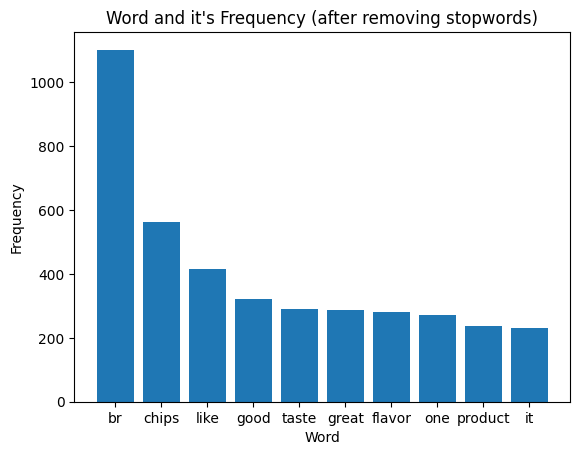

In [19]:
import matplotlib.pyplot as plt

plt.bar(top_words_removing_stopwords, top_counts_removing_stopwords)

plt.title("Word and it's Frequency (after removing stopwords)")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.show()

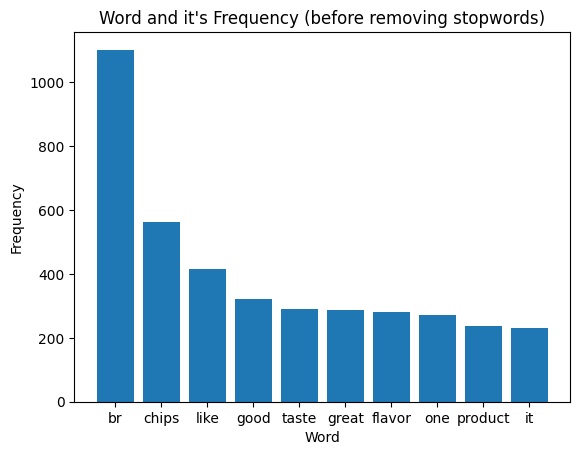

In [20]:
import matplotlib.pyplot as plt

plt.bar(top_words_without_removing_stopwords, top_counts_without_removing_stopwords)

plt.title("Word and it's Frequency (before removing stopwords)")
plt.xlabel("Word")
plt.ylabel("Frequency")

plt.show()

##### TF-IDF Vectorization

TF-IDF representation of product feedback

In [21]:
reviews = ["The smart speaker is incredible. Clear sound and fast responses!",
           "I am disappointed with the smart bulb. It stopped working in a week.",
           "The thermostat is okay. Not too smart, but functional."]

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

reviews = [preprocess(review) for review in reviews]

tfidf_matrix = vectorizer.fit_transform(reviews)

df = pd.DataFrame(
    data=tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

In [23]:
df.head()

,bulb,clear,disappointed,fast,functional,incredible,okay,responses,smart,sound,speaker,stopped,thermostat,week,working
0,0.000000,0.396875,0.000000,0.396875,0.000000,0.396875,0.000000,0.396875,0.234400,0.396875,0.396875,0.000000,0.000000,0.000000,0.000000
1,0.432385,0.000000,0.432385,0.000000,0.000000,0.000000,0.000000,0.000000,0.255374,0.000000,0.000000,0.432385,0.000000,0.432385,0.432385
2,0.000000,0.000000,0.000000,0.000000,0.546454,0.000000,0.546454,0.000000,0.322745,0.000000,0.000000,0.000000,0.546454,0.000000,0.000000


Comparing BoW and TF-IDF representations

In [24]:
import seaborn as sns

<Axes: >

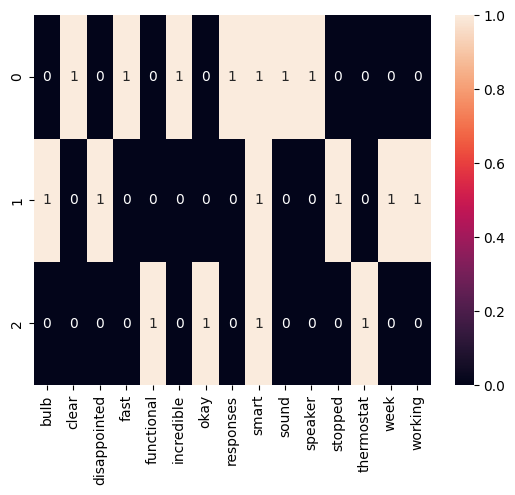

In [30]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

reviews = [preprocess(review) for review in reviews]

bow_matrix = vectorizer.fit_transform(reviews)

df = pd.DataFrame(
    data=bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

sns.heatmap(df, annot=True)

<Axes: >

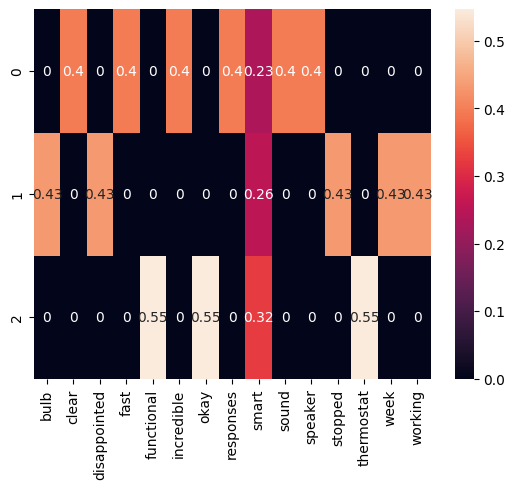

In [29]:
sns.heatmap(df, annot=True)

##### Embeddings

Exploring word relationships with embeddings

In [31]:
import gensim.downloader as api 
model = api.load('glove-wiki-gigaword-50') 
print(type(model)) 

[==================================================] 100.0% 66.0/66.0MB downloaded
<class 'gensim.models.keyedvectors.KeyedVectors'>


In [32]:
model["movie"]

array([ 0.30824 ,  0.17223 , -0.23339 ,  0.023105,  0.28522 ,  0.23076 ,
       -0.41048 , -1.0035  , -0.2072  ,  1.4327  , -0.80684 ,  0.68954 ,
       -0.43648 ,  1.1069  ,  1.6107  , -0.31966 ,  0.47744 ,  0.79395 ,
       -0.84374 ,  0.064509,  0.90251 ,  0.78609 ,  0.29699 ,  0.76057 ,
        0.433   , -1.5032  , -1.6423  ,  0.30256 ,  0.30771 , -0.87057 ,
        2.4782  , -0.025852,  0.5013  , -0.38593 , -0.15633 ,  0.45522 ,
        0.04901 , -0.42599 , -0.86402 , -1.3076  , -0.29576 ,  1.209   ,
       -0.3127  , -0.72462 , -0.80801 ,  0.082667,  0.26738 , -0.98177 ,
       -0.32147 ,  0.99823 ], dtype=float32)

In [33]:
# get the similarity score of king and queen
model.similarity("king", "queen")

np.float32(0.7839043)

In [34]:
# get top 10 words similar to the word "computer"
model.most_similar("computer", topn=10)

[('computers', 0.9165045022964478),
 ('software', 0.8814992904663086),
 ('technology', 0.852556049823761),
 ('electronic', 0.812586784362793),
 ('internet', 0.8060455322265625),
 ('computing', 0.802603542804718),
 ('devices', 0.8016185760498047),
 ('digital', 0.7991793751716614),
 ('applications', 0.7912740707397461),
 ('pc', 0.7883159518241882)]

Visualizing and comparing word embeddings

In [35]:
from sklearn.decomposition import PCA

words = ["lion", "tiger", "leopard", "banana", "strawberry", "truck", "car", "bus"]

word_vectors = [model[word] for word in words]

pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

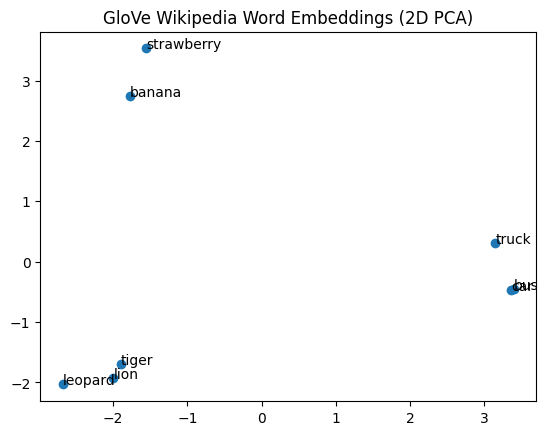

In [39]:
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1])

for word, (x, y) in zip(words, word_vectors_2d):
    plt.annotate(word, (x, y))
    
plt.title("GloVe Wikipedia Word Embeddings (2D PCA)")
plt.show()